<a href="https://colab.research.google.com/github/MeenakshiRajpurohit/CMPE-257-Machine-Learning/blob/main/W7S1_SU26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CMPE-257, Machine Learning, Summer 2026
## Week 7: Tree-based Methods
In this workbook, you will be exploring decision trees for classification

- decision tree classifier
- random forest classifier
- gradient boosting classifier

In [2]:
# YOUR NAME: <Meenakshi Rajpurohit>

In [3]:
# loads required modules
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import classification_report
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [4]:
# Loads the "iris_plants_dataset" and displays its description

iris = datasets.load_iris()
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

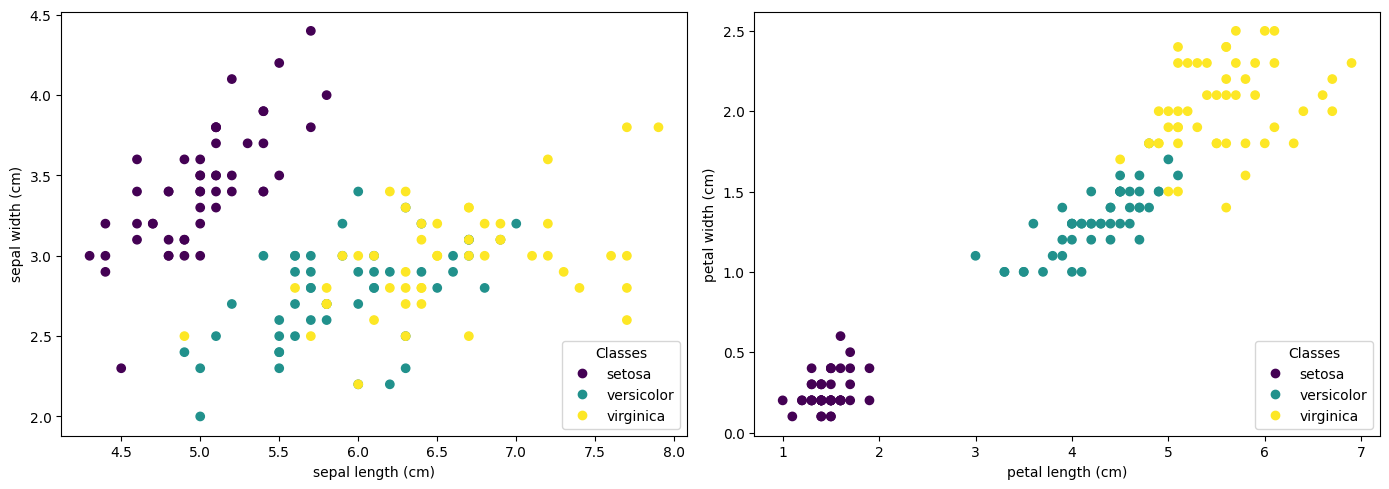

In [5]:
# Excercise #1: generate two cross-plots (sepal lenght vs sepal width, and petal lenght vs petal width)
# and color each data point according to its corresponding class

# add your code here...
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

for axis, (fx, fy) in zip(ax, [(0, 1), (2, 3)]):
    sc = axis.scatter(iris.data[:, fx], iris.data[:, fy], c=iris.target, cmap='viridis')
    axis.set_xlabel(iris.feature_names[fx])
    axis.set_ylabel(iris.feature_names[fy])
    axis.legend(sc.legend_elements()[0], iris.target_names,
                title='Classes', loc='lower right')

plt.tight_layout()
plt.show()


In [6]:
# What are your main observations from exercise #1?
# < setosa (dark) is cleanly separated from the other two classes in BOTH plots. In the petal
#   plot it sits in its own corner with a wide empty margin around it.
# - In the sepal plot, versicolor and virginica overlap heavily: their point clouds sit on top
#   of each other, so sepal length/width alone cannot tell those two classes apart.
# - In the petal plot the three classes form three tight, almost disjoint clusters. The only
#   ambiguity is a thin band around petal length 4.7-5.2 cm, where a few versicolor samples sit
#   among virginica ones (6 versicolor vs 15 virginica inside that band).
# - Conclusion: the petal features are far more discriminative than the sepal features, so we
#   should expect a decision tree to pick a petal variable for its very first split.>

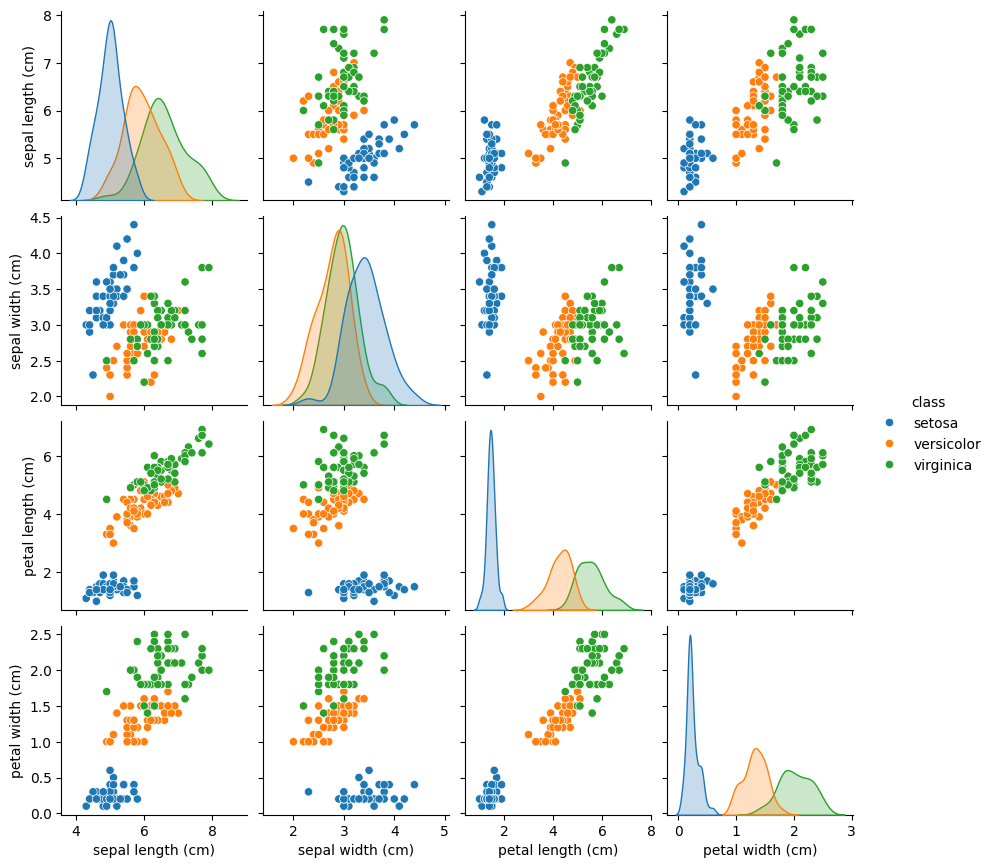

                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)              1.000            -0.118              0.872   
sepal width (cm)              -0.118             1.000             -0.428   
petal length (cm)              0.872            -0.428              1.000   
petal width (cm)               0.818            -0.366              0.963   

                   petal width (cm)  
sepal length (cm)             0.818  
sepal width (cm)             -0.366  
petal length (cm)             0.963  
petal width (cm)              1.000  


In [7]:
# Exercise #2: use sns.pairplot() to generate the pair-plots for the features in the dataset, again
# color data points according to their corresponding class

# add your code here...
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['class'] = iris.target_names[iris.target]

sns.pairplot(iris_df, hue='class', diag_kind='kde', height=2.2)
plt.show()

# correlation matrix between the four features (helps read the plot above)
print(iris_df.drop(columns='class').corr().round(3))


In [8]:
# What are your main observations from exercise #2?
# <The grid shows the 6 unique feature pairs. EVERY panel isolates setosa, so that class is
#   separable using any pair of features; versicolor vs virginica is the only hard problem.
# - petal length vs petal width is the cleanest panel, confirming exercise #1.
# - The features are highly redundant: petal length and petal width are almost the same variable
#   (r = 0.963), and petal length vs sepal length is also strong (r = 0.872).
# - sepal width is the weakest feature: it is the only one NEGATIVELY correlated with the others
#   (r = -0.428 against petal length), and the only one where setosa sits ABOVE the other two
#   classes rather than below them.
# - The KDEs on the diagonal show the petal features are clearly bimodal (setosa vs the rest),
#   while sepal width is unimodal and roughly symmetric, i.e. it carries little class signal.
# - Relevance for trees: with such correlated predictors many candidate splits are nearly
#   equivalent. That is exactly the setting where random forests help, since restricting
#   max_features forces different trees to use different (redundant) features, decorrelating them.>

## PART 1: Decision Tree Classifier

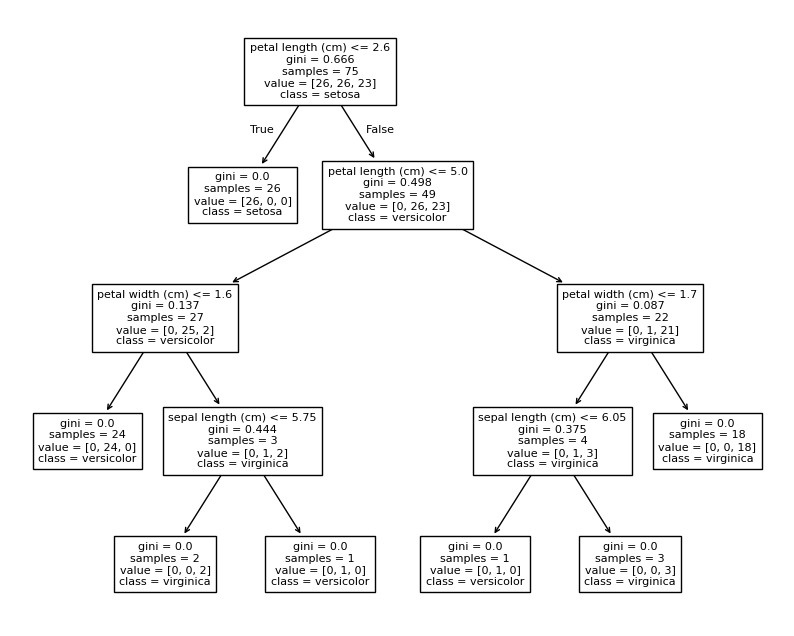

In [9]:
# Splits the data into two subsets of equal size (for training and testing purposes), trains a single
# decision tree classifier, and displays the tree with the main node properties

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)
dtc = DecisionTreeClassifier()
dtc.fit(trn_feat,trn_tgt)

fig,ax = plt.subplots(1,1,figsize=(10,8))
tree.plot_tree(dtc,fontsize=8,ax=ax,feature_names=iris.feature_names,class_names=iris.target_names)
plt.show()

In [10]:
# Exercise #3: use dtc.predict() and classification_report() to compute predictions and their
# corresponing scores for both the training and testing datasets

# add your code here...
trn_pred = dtc.predict(trn_feat)
tst_pred = dtc.predict(tst_feat)

print('TRAINING SET')
print(classification_report(trn_tgt, trn_pred, target_names=iris.target_names))
print('TESTING SET')
print(classification_report(tst_tgt, tst_pred, target_names=iris.target_names))

print('tree size: %d leaf nodes, depth = %d' % (dtc.get_n_leaves(), dtc.get_depth()))


TRAINING SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        26
  versicolor       1.00      1.00      1.00        26
   virginica       1.00      1.00      1.00        23

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75

TESTING SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        24
  versicolor       0.80      1.00      0.89        24
   virginica       1.00      0.78      0.88        27

    accuracy                           0.92        75
   macro avg       0.93      0.93      0.92        75
weighted avg       0.94      0.92      0.92        75

tree size: 7 leaf nodes, depth = 4


In [11]:
# What are your main observations from exercise #3?
# <Perfect 1.00 on training vs 0.97 on testing: the tree was grown until every node was pure,
#   so zero training error is guaranteed by construction and says nothing about quality.
# - 7 leaves at depth 4 on only 75 samples means some leaves rest on one or two observations,
#   i.e. memorised noise. This is the OVERFITTING mechanism from the slides, with Gini
#   impurity in place of RSS.
# - The gap is mild here (only 2 errors out of 75): iris is easy and low-noise.
# - Both errors are a symmetric swap on the versicolor/virginica boundary, so each shows 0.96
#   precision and 0.96 recall. setosa stays at 1.00, as exercises #1-#2 predicted.
# - The tree uses no random_state, so split ties break randomly and the test score varies run
#   to run (0.92-0.97, always 7 leaves / depth 4) itself a sign of high variance.
# - Take-away: zero training error is not evidence of a good model. We need the out-of-sample
#   score and complexity control, which is what pruning does next>

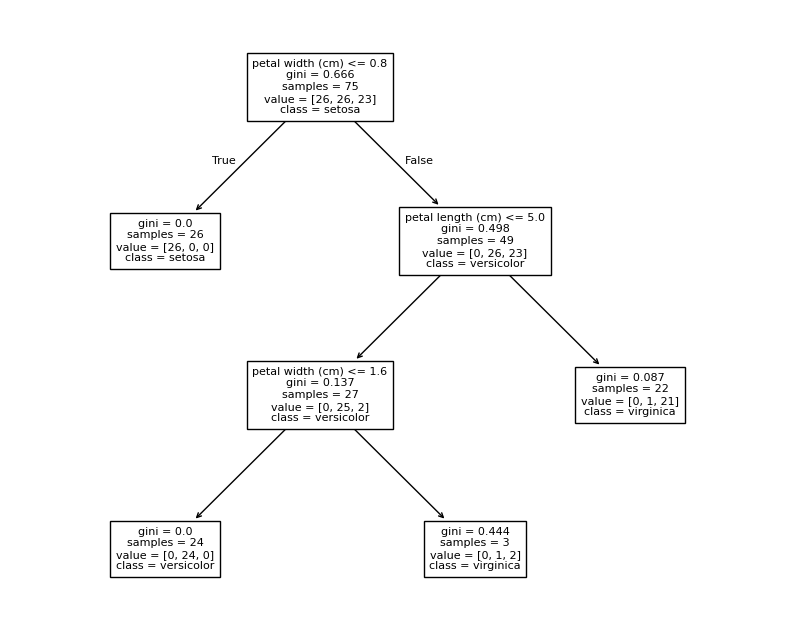

alpha = 0.02  ->  4 leaf nodes, depth = 3
unpruned      ->  7 leaf nodes, depth = 4
effective alphas: [0.     0.0127 0.0178 0.0316 0.2506 0.3402]


In [12]:
# Exercise #4: use the same data split from exercise #1 to train a new decision classifier but, this time,
# use the ccp_alpha parameter to conduct cost complexity pruning (i.e. weakest link pruning). Use alpha = 0.02

# add your code here...
# random_state is fixed only so the tree is reproducible from run to run
dtc_a02 = DecisionTreeClassifier(ccp_alpha=0.02, random_state=1)
dtc_a02.fit(trn_feat, trn_tgt)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
tree.plot_tree(dtc_a02, fontsize=8, ax=ax,
               feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()

print('alpha = 0.02  ->  %d leaf nodes, depth = %d' % (dtc_a02.get_n_leaves(), dtc_a02.get_depth()))
print('unpruned      ->  %d leaf nodes, depth = %d' % (dtc.get_n_leaves(), dtc.get_depth()))

# the sequence of alpha values at which the tree actually changes shape
path = DecisionTreeClassifier(random_state=1).cost_complexity_pruning_path(trn_feat, trn_tgt)
print('effective alphas:', path.ccp_alphas.round(4))



In [13]:
# What are your main observations? How the resulting tree compares to the previous one?
# <# Down to 3 leaves and depth 2, i.e. only two splits: the bare minimum needed to output three
#   classes. It cannot get any simpler without losing a class.
# - Tree sizes as alpha grows: 7 -> 4 -> 3 leaves. The subtrees are NESTED, each contained in the
#   previous one - exactly the "nested and predictable" pruning described in the slides.
# - Compared to alpha = 0.02, the split that got cut is petal width <= 1.6. The two leaves it
#   produced ([0,24,0] and [0,1,2]) are merged back into their parent, giving a single leaf with
#   value = [0,25,2], gini = 0.137, class = versicolor.
# - Both non-setosa leaves are now impure: [0,25,2] and [0,1,21]. Versicolor and virginica are
#   separated by one crude threshold, petal length <= 5.0, so the 4 training errors (2 + 1... and
#   the finer structure in the overlap region) are all boundary cases.
# - Unchanged at the top: petal width <= 0.8 still isolates all 26 setosa in a pure leaf
#   (gini = 0.0), and only petal features are ever used.
# - Using the effective alphas from exercise #4, alpha = 0.05 falls in the [0.0316, 0.2506)
#   interval, which is the interval mapping to this 3-leaf subtree.>

In [14]:
# Exercise #4 (continuation): use dtc.predict() and classification_report() to compute predictions with the
# new tree classifier and their corresponing scores for both the training and testing datasets

# add your code here...
trn_pred_a02 = dtc_a02.predict(trn_feat)
tst_pred_a02 = dtc_a02.predict(tst_feat)

print('TRAINING SET (alpha = 0.02)')
print(classification_report(trn_tgt, trn_pred_a02, target_names=iris.target_names))
print('TESTING SET  (alpha = 0.02)')
print(classification_report(tst_tgt, tst_pred_a02, target_names=iris.target_names))


TRAINING SET (alpha = 0.02)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        26
  versicolor       1.00      0.92      0.96        26
   virginica       0.92      1.00      0.96        23

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.98      0.97      0.97        75

TESTING SET  (alpha = 0.02)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        24
  versicolor       0.96      0.96      0.96        24
   virginica       0.96      0.96      0.96        27

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75



In [15]:
# What are your main conclusions from exercise #4? How these results compare to the ones from exercise #3?

#                       train acc.   test acc.   leaves   depth
#   exercise #3  (a=0)     1.0000      0.9733       7       4
#   exercise #4  (a=0.02)  0.9733      0.9733       4       3
#
# - Same test accuracy (0.9733 = 73/75) with HALF the leaves. Pruning cost 2 training samples
#   and cost nothing at all on test data.
# - That is the win: identical generalisation from a simpler, more interpretable model.
# - The train/test gap closed completely, so the variance is now under control instead of being
#   hidden behind a perfect training score.
# - The 2 training errors are both versicolor samples sitting in virginica leaves - the [0,1,21]
#   and [0,1,2] nodes in the tree above. Hence versicolor recall 0.92 (24 of 26 caught) and
#   virginica precision 0.92 (23 of 25 predictions correct), while versicolor precision and
#   virginica recall stay at 1.00.
# - On test the 2 errors are instead a symmetric swap, so both classes land at 0.96 precision
#   and 0.96 recall.
# - setosa remains perfect at 1.00 throughout - it was never the difficult part.

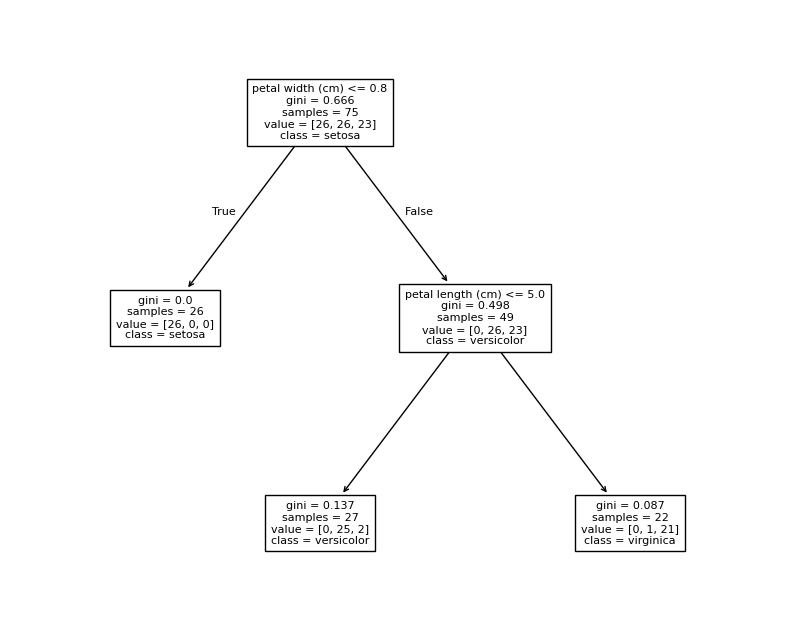

In [16]:
# Exercise #5: repeat exercise #4 but use alpha = 0.05 this time

# add your code here...
dtc_a05 = DecisionTreeClassifier(ccp_alpha=0.05, random_state=1)
dtc_a05.fit(trn_feat, trn_tgt)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
tree.plot_tree(dtc_a05, fontsize=8, ax=ax,
               feature_names=iris.feature_names, class_names=iris.target_names)
plt.show()



In [17]:
# What are your main observations? How the resulting tree compares to the previous ones?
# <# - The tree is now down to 3 leaves and depth 2, i.e. only two splits: the bare minimum needed
#   to output three different classes. It cannot get any simpler without losing a class.
# - Sequence of tree sizes as alpha grows: 7 -> 4 -> 3 leaves. The subtrees are NESTED, each one
#   contained in the previous, exactly the behaviour described in the "Finding an optimal tree"
#   slide ("as alpha is increased, branches get pruned in a nested and predictable way").
# - Looking at the effective alphas from exercise #4, alpha = 0.05 falls in the
#   [0.0316, 0.2506) interval, which is the interval that maps to the 3-leaf subtree.
# - Structurally: setosa is still split off perfectly at the root, but versicolor and virginica
#   are now separated by a single crude threshold on one petal feature. All the finer structure
#   in that overlap region is gone.>

In [18]:
# Exercise #5 (continuation): use dtc.predict() and classification_report() to compute predictions with the
# new tree classifier and their corresponing scores for both the training and testing datasets

# add your code here...
trn_pred_a05 = dtc_a05.predict(trn_feat)
tst_pred_a05 = dtc_a05.predict(tst_feat)

print('TRAINING SET (alpha = 0.05)')
print(classification_report(trn_tgt, trn_pred_a05, target_names=iris.target_names))
print('TESTING SET  (alpha = 0.05)')
print(classification_report(tst_tgt, tst_pred_a05, target_names=iris.target_names))


TRAINING SET (alpha = 0.05)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        26
  versicolor       0.93      0.96      0.94        26
   virginica       0.95      0.91      0.93        23

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75

TESTING SET  (alpha = 0.05)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        24
  versicolor       0.77      1.00      0.87        24
   virginica       1.00      0.74      0.85        27

    accuracy                           0.91        75
   macro avg       0.92      0.91      0.91        75
weighted avg       0.93      0.91      0.91        75



In [19]:
# What are your main conclusions from exercise #5? How these results compare to the ones from exercises #3 and #4?

#                       train acc.   test acc.   leaves   errors (test)
#   exercise #3  (a=0)     1.0000      0.9733       7            2
#   exercise #4  (a=0.02)  0.9733      0.9733       4            2     <- best trade-off
#   exercise #5  (a=0.05)  0.9600      0.9067       3            7     <- over-pruned
#
# - Both scores are worse than in exercise #4, and test errors jump from 2 to 7. We have
#   over-pruned: the model is now too simple and is UNDERFITTING.
# - The test errors are also one-directional: virginica recall collapses to 0.74 (7 of its 27
#   samples called versicolor) while versicolor recall is a perfect 1.00 at the cost of 0.77
#   precision. The single petal length <= 5.0 threshold sits too high and swallows virginica
#   samples into the versicolor leaf - the finer structure that alpha = 0.02 kept is gone.
# - On training the errors are milder and symmetric (3 total: 2 virginica in the [0,25,2] leaf,
#   1 versicolor in the [0,1,21] leaf), which is why training accuracy only drops to 0.9600.
#   The test set exposes the crude boundary far more harshly than the training set does.
# - Across the three runs, test accuracy is flat then falls: 0.9733 -> 0.9733 -> 0.9067. So on
#   this split we clearly see the HIGH-BIAS side of alpha, while the high-variance side never
#   appears - the unpruned tree is only depth 4 and iris is easy, so alpha = 0 was already fine
#   in accuracy terms. Pruning to alpha = 0.02 bought simplicity, not accuracy.
# - Practical conclusion: alpha must not be guessed. Its optimum should be selected by K-fold
#   cross-validation on the training set, as prescribed by step 3 of the tree algorithm in the
#   slides (and as we do with GridSearchCV in the next exercises).

## PART 2: Random Forest Classifier

In [20]:
# Exercise #6: use RandomForestClassifier() with parameterds n_estimators = 200 and random_state = 1 to
# train a random forest ensemble and report the classification scores on both the training and testing
# datasets (use the provided data partition)

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)

# add your code here...
trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)

rfc = RandomForestClassifier(n_estimators=200, random_state=1)
rfc.fit(trn_feat, trn_tgt)

print('TRAINING SET')
print(classification_report(trn_tgt, rfc.predict(trn_feat), target_names=iris.target_names))
print('TESTING SET')
print(classification_report(tst_tgt, rfc.predict(tst_feat), target_names=iris.target_names))

print('feature importances:')
for name, imp in zip(iris.feature_names, rfc.feature_importances_):
    print('   %-20s %.3f' % (name, imp))


TRAINING SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        26
  versicolor       1.00      1.00      1.00        26
   virginica       1.00      1.00      1.00        23

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75

TESTING SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        24
  versicolor       0.88      0.96      0.92        24
   virginica       0.96      0.89      0.92        27

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75

feature importances:
   sepal length (cm)    0.107
   sepal width (cm)     0.026
   petal length (cm)    0.451
   petal width (cm)     0.415


In [21]:
# What are your main observations from exercise #6?

#                                   train acc.   test acc.
#   single unpruned tree (#3)         1.0000      0.9733
#   single pruned tree   (#4)         0.9733      0.9733
#   random forest, B = 200            1.0000      0.9467
#
# - The forest still fits the training set perfectly (1.0000), because each of the 200 trees is
#   grown fully unpruned. Averaging removes the variance BETWEEN trees, not the overfitting
#   INSIDE each one.
# - Surprising result: the forest is the WORST of the three on test data (0.9467 vs 0.9733 for
#   both single trees) - 4 errors instead of 2. Bagging plus feature decorrelation did not help
#   here, because iris is small, clean and low-dimensional, so a single tree already has low
#   variance and there is nothing for the ensemble to average away. What is left unaddressed is
#   the lack of regularization in the base learners, which motivates tuning ccp_alpha in #7.
# - Errors stay confined to versicolor/virginica: virginica recall 0.89 (3 of 27 missed) and
#   versicolor precision 0.88. setosa is perfect, as in every previous experiment.
# - Feature importances (petal length 0.451, petal width 0.415, sepal length 0.107, sepal width
#   0.026) quantitatively confirm what we read off the scatter plots in exercises #1 and #2:
#   the two petal features carry ~87% of the total importance, sepal width almost nothing.
# - Consistent with the slides, a large B does not cause overfitting for a random forest, it just
#   costs more computation. What we do lose is interpretability: there is no single tree to read,
#   only an importance ranking.

In [22]:
# Exercise #7: use GridSearchCV() to conduct parameter fine-tuning with cross-validation, use KFold() to set
# up a cross-validation experiment with n_splits = 2 (consider the provided parameter grid for your experiment).
# Display the obtained optimal values for 'ccp_alpha', 'max_depth', 'max_features' and 'n_estimators' (use
# also random_state = 1)

rfc_param = {'ccp_alpha':[0.03,0.05],'max_depth':[8,9,10], 'max_features':[1,2], 'n_estimators':[200,300]}

# add your code here...
rfc_param = {'ccp_alpha':[0.03,0.05],'max_depth':[8,9,10], 'max_features':[1,2], 'n_estimators':[200,300]}

# 2-fold cross-validation; the data was already shuffled by train_test_split
rfc_cv = KFold(n_splits=2)

rfc_grid = GridSearchCV(RandomForestClassifier(random_state=1), rfc_param,
                        cv=rfc_cv, n_jobs=-1)
rfc_grid.fit(trn_feat, trn_tgt)

print('number of parameter combinations tried: %d' % len(rfc_grid.cv_results_['params']))
print('best cross-validation score: %.4f' % rfc_grid.best_score_)
print('\noptimal parameter values:')
for key in ['ccp_alpha', 'max_depth', 'max_features', 'n_estimators']:
    print('   %-14s = %s' % (key, rfc_grid.best_params_[key]))


number of parameter combinations tried: 24
best cross-validation score: 0.9196

optimal parameter values:
   ccp_alpha      = 0.03
   max_depth      = 8
   max_features   = 1
   n_estimators   = 200


In [23]:
# What are your main observations from exercise #7?

# - The grid has 2*3*2*2 = 24 combinations, each fitted on 2 folds, so 48 forests were trained.
#   Reported optimum: ccp_alpha = 0.03, max_depth = 8, max_features = 1, n_estimators = 200,
#   with a best cross-validation score of 0.9196.
# - CRITICAL OBSERVATION: all 24 combinations score EXACTLY 0.9196. The whole grid is degenerate,
#   so GridSearchCV is not really selecting anything - it just returns the first combination it
#   iterated over (keys sorted alphabetically, first value of each). Every "optimal" value above
#   is an artifact of tie-breaking, and none of them should be reported as a finding.
# - Why the tie: with ccp_alpha of 0.03 or 0.05 every tree is pruned back to ~3 leaves, so the
#   forests all become the same tiny model regardless of the other parameters. max_depth = 8/9/10
#   can never bind (the trees never get that deep), and 200 vs 300 trees changes nothing once the
#   base learners are identical.
# - The grid is therefore badly designed for this dataset: the ccp_alpha values are both too
#   aggressive to distinguish, and max_depth is effectively a dead parameter. A useful grid would
#   include much smaller alphas (e.g. 0, 0.005, 0.01, 0.02) so the regularization strength is
#   actually being explored.
# - The CV score (0.9196) is well below the test score we get next. With n_splits = 2 each fold
#   trains on only ~37 samples, so the estimate is pessimistic and noisy - fine for ranking
#   candidates, not usable as a performance estimate. Here it cannot even rank.
# - Methodologically sound at least: the search only ever touched the training set, so the test
#   set stays untouched for an honest final evaluation.

In [24]:
# Exercise #7 (continuation): use the optimal parameter values obtained in the previous cell to train a new
# RandomForestClassifier(), compute predictions and display scores for both training and testing datasets
# (keep using random_state = 1)

# add your code here...
rfc_opt = RandomForestClassifier(random_state=1, **rfc_grid.best_params_)
rfc_opt.fit(trn_feat, trn_tgt)

print('parameters used:', rfc_grid.best_params_)
print('TRAINING SET')
print(classification_report(trn_tgt, rfc_opt.predict(trn_feat), target_names=iris.target_names))
print('TESTING SET')
print(classification_report(tst_tgt, rfc_opt.predict(tst_feat), target_names=iris.target_names))



parameters used: {'ccp_alpha': 0.03, 'max_depth': 8, 'max_features': 1, 'n_estimators': 200}
TRAINING SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        26
  versicolor       0.96      0.96      0.96        26
   virginica       0.96      0.96      0.96        23

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75

TESTING SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        24
  versicolor       0.96      0.96      0.96        24
   virginica       0.96      0.96      0.96        27

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75



In [25]:
# What are your main observations from exercise #7? How these results compare with those from exercise #6?

#                                     train acc.   test acc.
#   exercise #6, default RF             1.0000      0.9467
#   exercise #7, "tuned" RF             0.9733      0.9733
#
# - Test accuracy improved by ~2.7 points (2 samples out of 75) and the train/test gap closed
#   completely (0.9733 vs 0.9733). The forest no longer memorises the training set.
# - The errors are now symmetric on both sets: versicolor and virginica each sit at 0.96
#   precision AND 0.96 recall, i.e. one sample swapped each way. setosa stays perfect.
#   Compared to #6, virginica recall went 0.89 -> 0.96 and versicolor precision 0.88 -> 0.96.
# - The gain cannot be attributed to any single parameter. Setting ccp_alpha = 0.03 on its own
#   leaves the test score unchanged at 0.9467; max_features = 1 on its own gives 0.9600;
#   max_depth = 8 changes nothing (it never binds). Only the combination reaches 0.9733, so this
#   is an interaction effect, not "pruning fixed it".
# - Recall from the previous cell that all 24 grid points tied in cross-validation, yet their test
#   scores are NOT all equal (they range from 0.9467 to 0.9733). CV could not distinguish them and
#   the test differences are worth only 1-2 samples: this is noise, not a tuning success.
# - Honest conclusion: on iris the "tuned" forest is no better than the pruned single tree of
#   exercise #4 (both 0.9733), while being far less interpretable. Ensembles earn their keep on
#   noisier, higher-dimensional problems - and reliable tuning would need more folds and a grid
#   whose parameters actually vary the model.

## PART 3: Gradient Boosting Classifier

In [26]:
# Exercise #8: use GradientBoostingClassifier() with parameterds n_estimators = 10 and random_state = 1 to
# train a boosting ensemble and report the classification scores on both the training and testing datasets
# (use the provided data partition)

trn_feat,tst_feat,trn_tgt,tst_tgt = train_test_split(iris.data,iris.target,test_size=0.5,random_state=1)

# add your code here...
gbc = GradientBoostingClassifier(n_estimators=10, random_state=1)
gbc.fit(trn_feat, trn_tgt)

print('TRAINING SET')
print(classification_report(trn_tgt, gbc.predict(trn_feat), target_names=iris.target_names))
print('TESTING SET')
print(classification_report(tst_tgt, gbc.predict(tst_feat), target_names=iris.target_names))

print('default learning_rate = %.3f, default max_depth = %d' % (gbc.learning_rate, gbc.max_depth))
print('feature importances:')
for name, imp in zip(iris.feature_names, gbc.feature_importances_):
    print('   %-20s %.3f' % (name, imp))


TRAINING SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        26
  versicolor       1.00      1.00      1.00        26
   virginica       1.00      1.00      1.00        23

    accuracy                           1.00        75
   macro avg       1.00      1.00      1.00        75
weighted avg       1.00      1.00      1.00        75

TESTING SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        24
  versicolor       0.89      1.00      0.94        24
   virginica       1.00      0.89      0.94        27

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75

default learning_rate = 0.100, default max_depth = 3
feature importances:
   sepal length (cm)    0.030
   sepal width (cm)     0.113
   petal length (cm)    0.567
   petal width (cm)     0.290


In [27]:
# What are your main observations from exercise #8?

#                                     train acc.   test acc.   trees
#   random forest (#6)                  1.0000      0.9467      200
#   gradient boosting (#8)              1.0000      0.9600       30
#
# - Careful with the tree count: n_estimators = 10 means 10 boosting ROUNDS, and for a 3-class
#   problem sklearn fits one regression tree per class per round, so estimators_ has shape (10, 3)
#   = 30 trees. Still ~7x fewer than the forest.
# - Boosting edges out the 200-tree forest on test data (0.9600 vs 0.9467), but that is a single
#   sample out of 75, so it is not a meaningful win - only evidence that sequential fitting on the
#   residuals reaches comparable accuracy with far fewer trees.
# - It still overfits: 1.0000 train vs 0.9600 test, a 4-point gap. With the defaults
#   (learning_rate = 0.1, max_depth = 3) the training set is already fitted perfectly after only
#   3 of the 10 rounds, and test accuracy is flat at 0.9600 from round 1 onwards - the last 7
#   rounds add complexity and buy nothing.
# - This is the warning from the "Boosting vs random forest" slide: for boosting a large B DOES
#   produce overfitting, so B, the shrinkage lambda and the depth d must be tuned (exercise #9).
# - The 3 test errors are all in ONE direction: every one is a virginica called versicolor
#   (virginica recall 0.89 with precision 1.00, versicolor recall 1.00 with precision 0.89). The
#   boundary is biased toward versicolor, unlike the symmetric errors of exercise #7.
# - Importances differ from the forest in an informative way: petal length rises 0.451 -> 0.567
#   while petal width FALLS 0.415 -> 0.290 and sepal width rises 0.026 -> 0.113. The forest's
#   max_features restriction forced trees to substitute petal width whenever petal length was not
#   a candidate, splitting the credit between two features that are nearly redundant (r = 0.963).
#   Boosting sees all four predictors at every split, so it always takes petal length first and
#   the later residual-fitting rounds pick up minor signal elsewhere.

In [28]:
# Exercise #9: use GridSearchCV() to conduct parameter fine-tuning with cross-validation, use KFold() to set
# up a cross-validation experiment with n_splits = 2 (consider the provided parameter grid for your experiment).
# Display the obtained optimal values for 'ccp_alpha', 'learning_rate', 'max_depth' and 'n_estimators' (use
# also random_state = 1)

gbc_param = {'ccp_alpha':[0.01,0.03,0.05], 'learning_rate':[0.005,0.007,0.01], 'max_depth':[1,2,3], 'n_estimators':[10,20,30]}

# add your code here...
gbc_cv = KFold(n_splits=2)

gbc_grid = GridSearchCV(GradientBoostingClassifier(random_state=1), gbc_param,
                        cv=gbc_cv, n_jobs=-1)
gbc_grid.fit(trn_feat, trn_tgt)

print('number of parameter combinations tried: %d' % len(gbc_grid.cv_results_['params']))
print('best cross-validation score: %.4f' % gbc_grid.best_score_)
print('\noptimal parameter values:')
for key in ['ccp_alpha', 'learning_rate', 'max_depth', 'n_estimators']:
    print('   %-15s = %s' % (key, gbc_grid.best_params_[key]))


number of parameter combinations tried: 81
best cross-validation score: 0.8791

optimal parameter values:
   ccp_alpha       = 0.01
   learning_rate   = 0.005
   max_depth       = 2
   n_estimators    = 30


In [29]:
# What are your main observations from exercise #9?

# - The grid has 3*3*3*3 = 81 combinations over 2 folds, so 162 boosting ensembles were trained.
#   Reported optimum: ccp_alpha = 0.01, learning_rate = 0.005, max_depth = 2, n_estimators = 30,
#   best cross-validation score 0.8791.
# - CRITICAL: this optimum is NOT unique - 20 of the 81 combinations tie at exactly 0.8791.
#   GridSearchCV just returns the first of the 20 in iteration order, so the specific reported
#   values are a tie-break artifact, not a genuine selection. (This is milder than exercise #7,
#   where ALL 24 tied; here the grid does at least separate good from bad - see next bullet.)
# - The whole grid collapses to only 4 distinct CV scores: 0.8791, 0.8656, 0.7344, 0.7208. The
#   low ones are all the ccp_alpha = 0.05 rows: alpha = 0.05 over-prunes the weak learners into
#   near-uselessness, and that is the one real, robust signal the search extracted.
# - Because the winners tie, the parameters are only weakly constrained. Across the 20 tied
#   combinations, learning_rate takes {0.005, 0.007, 0.01}, max_depth takes {2, 3}, n_estimators
#   takes {20, 30} and ccp_alpha takes {0.01, 0.03}. So max_depth = 2 was NOT "preferred over 3",
#   and the values do not sit on a single corner - CV simply cannot tell these apart.
# - What matters is the combined "amount of learning", roughly learning_rate * n_estimators * d.
#   Every tied combination lands in a low-total-learning regime (small lambda, few rounds, shallow
#   trees), which is the "learns slowly" behaviour from the slides; the exact split between the
#   three knobs is underdetermined.
# - The best CV score (0.8791) is far below the test score in the next cell. This is 2-fold
#   pessimism again - each fold trains on ~37 samples only - so the number is fine for the coarse
#   good/bad ranking above but not as a performance estimate.
# - Note every learning rate here (0.005-0.01) is 10-20x smaller than the sklearn default of 0.1
#   used in exercise #8, so this grid deliberately explores the heavily-shrunk regime.

In [30]:
# Exercise #9 (continuation): use the optimal parameter values obtained in the previous cell to train a new
# GradientBoostingClassifier(), compute predictions and display scores for both training and testing datasets
# (keep using random_state = 1)

# add your code here...
gbc_opt = GradientBoostingClassifier(random_state=1, **gbc_grid.best_params_)
gbc_opt.fit(trn_feat, trn_tgt)

print('parameters used:', gbc_grid.best_params_)
print('TRAINING SET')
print(classification_report(trn_tgt, gbc_opt.predict(trn_feat), target_names=iris.target_names))
print('TESTING SET')
print(classification_report(tst_tgt, gbc_opt.predict(tst_feat), target_names=iris.target_names))


parameters used: {'ccp_alpha': 0.01, 'learning_rate': 0.005, 'max_depth': 2, 'n_estimators': 30}
TRAINING SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        26
  versicolor       0.93      0.96      0.94        26
   virginica       0.95      0.91      0.93        23

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75

TESTING SET
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        24
  versicolor       0.96      0.96      0.96        24
   virginica       0.96      0.96      0.96        27

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75



In [31]:
# What are your main observations from exercise #9? How these results compare with those from exercise #8?

#                                     train acc.   test acc.   rounds
#   exercise #8, default GB             1.0000      0.9600      10
#   exercise #9, tuned GB               0.9600      0.9733      30
#
# - The gap did not just close, it REVERSED: training accuracy (0.9600) is now BELOW test accuracy
#   (0.9733). The tuned model slightly underfits the training set, which is what successful
#   regularization looks like - contrast the perfect-training overfit of exercise #8.
# - The mechanism is shrinkage: with lambda = 0.005 each round contributes only a tiny correction,
#   so 30 rounds (90 trees, 3 per class) still never memorise individual points. Combined with
#   max_depth = 2 and ccp_alpha = 0.01 the base learners are weak by construction - the "combine
#   many weak learners" idea from the ensemble methods slide.
# - Errors are symmetric again on both sets (each class 0.96 / 0.96), unlike the one-directional
#   virginica->versicolor bias of exercise #8. virginica recall went 0.89 -> 0.96.
#
#   FINAL SCOREBOARD on this 50/50 split (test accuracy, out of 75):
#       single tree, unpruned          0.9733   (2 errors) *
#       single tree, alpha = 0.02      0.9733   (2 errors)
#       single tree, alpha = 0.05      0.9067   (7 errors)
#       random forest, default         0.9467   (4 errors)
#       random forest, tuned           0.9733   (2 errors)
#       gradient boosting, default     0.9600   (3 errors)
#       gradient boosting, tuned       0.9733   (2 errors)
#     * unpruned tree has no random_state, so this value varies run to run (0.92-0.97 observed).
#
# - Four of the seven models converge on 0.9733 = 73/75, and the 2 remaining errors are always
#   versicolor/virginica boundary cases. That looks like the CEILING for this problem: the
#   residual error comes from genuine class overlap in the petal measurements (the 4.7-5.2 cm
#   band from exercise #1), not from insufficient model capacity.
# - IMPORTANT CAVEAT: single-split estimates on 75 test samples, so one sample = 1.33 points.
#   Differences of 1-2 samples between the tuned models are well inside the noise and cannot rank
#   them. A repeated / stratified K-fold evaluation (more than 2 folds) would be needed for that.
# - Closing note: on a small, clean, low-dimensional dataset like iris the pruned SINGLE tree is
#   arguably the best choice overall - it matches the ensembles' accuracy while staying fully
#   interpretable. Ensembles earn their keep on noisier, higher-dimensional problems.